# 03 · Pose density: two sites, and what places them

Every pose is Kabsch-aligned by its protein CA to one common reference frame; the ligand centroid is taken in that frame. This asks where Boltz-2 puts the ligands, whether actives concentrate, whether unseen-scaffold actives go where seen ones do, and whether placement or ligand properties drive the score.

Headline: the poses fall into two sites, not one - my first pass used DBSCAN eps=6 A which bridged them. Corrected here with k=2 clustering.

Caveats: one (easy) target, ~70% folded (check split stability as it completes); common frame = one reference pose; the SAM/SAH pocket is treated as the cofactor site, and the second site's residues are compared to the known NS5 GTP/cap site.

In [1]:

import json, glob, gzip, os, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib as mpl, matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold
from sklearn.cluster import KMeans
from IPython.display import display
warnings.filterwarnings("ignore")
BLK="#000000"; ACTIVE="#0e9f6e"; INACT="#c8ccd2"; POCKET="#e34948"; SITEA="#7b8494"; SITEB="#2a78d6"; SEEN="#eda100"; UNSEEN="#4a3aa7"
mpl.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","savefig.facecolor":"white",
  "text.color":BLK,"axes.labelcolor":BLK,"axes.titlecolor":BLK,"xtick.color":BLK,"ytick.color":BLK,
  "axes.edgecolor":BLK,"font.size":10,"font.weight":"normal","axes.titleweight":"normal","axes.labelweight":"normal",
  "axes.grid":True,"grid.color":"#e6e6e6","axes.axisbelow":True,"axes.spines.top":False,"axes.spines.right":False})
ROOT=Path("/global/scratch/users/sergiomar10/boltzaff"); R=ROOT/"results/runs/588689"; PD=R/"pose_density"
ref_ca=np.load(PD/"ref_ca.npy"); pocket=np.array(json.loads((PD/"pocket.json").read_text())["sah_centroid"])
ref_pose=json.loads((PD/"pocket.json").read_text())["ref_pose"]
cen=pd.concat([pd.read_csv(f) for f in glob.glob(str(PD/"centroids_chunk_*.csv")) if os.path.getsize(f)>1]).drop_duplicates("CID")
df=pd.read_csv(ROOT/"data/588689_results.csv"); df["CID"]=df.CID.astype(int)
ids=[int(x.strip().removeprefix("588689_")) for x in gzip.open(ROOT/"BoltzFT/data/splits/588689.txt.gz","rt")]
df=df.set_index("CID").loc[ids].reset_index(); df["rank"]=np.arange(1,len(df)+1)
df["scaf"]=[MurckoScaffold.MurckoScaffoldSmiles(mol=m) if (m:=Chem.MolFromSmiles(str(s))) else None for s in df["neut-smiles"]]
train300=set(s for s in df.scaf[:300] if s); df["seen_scaffold"]=df.scaf.isin(train300)
qc=pd.read_csv(R/"qc.csv")[["CID","complex_plddt","ligand_iptm"]]
d=cen.merge(df[["CID","neut-smiles","Active_v2","rank","scaf","seen_scaffold","affinity_probability_binary"]],on="CID").merge(qc,on="CID",how="left")
good=d[d.ca_rmsd<=np.percentile(d.ca_rmsd,95)].copy()
km=KMeans(2,n_init=10,random_state=0).fit(good[["x","y","z"]].values); good["kc"]=km.labels_
sah_k=int(np.argmin([np.linalg.norm(c-pocket) for c in km.cluster_centers_]))
good["site"]=np.where(good.kc==sah_k,"SAH_pocket","site_A(cap-like)")
def wilson(k,n,z=1.96):
    p=k/n; dd=1+z*z/n; c=(p+z*z/(2*n))/dd; s=z*np.sqrt(p*(1-p)/n+z*z/(4*n*n))/dd; return (c-s,c+s)
print(f"centroids merged: {len(d)}   kept (CA-fit <= p95): {len(good)}   actives: {int(good.Active_v2.sum())}")


centroids merged: 36432   kept (CA-fit <= p95): 34610   actives: 356


## QC + frame-artifact check
Filter poor CA fits, then confirm the two clusters are not an alignment artifact: they must persist among well-aligned poses (CA-fit RMSD <= 2 A).

In [2]:
print(good.groupby("site").ca_rmsd.agg(["median","max"]).round(2).to_string())
lowr=good[good.ca_rmsd<=2.0]
k2=KMeans(2,n_init=10,random_state=0).fit(lowr[["x","y","z"]].values)
sep=np.linalg.norm(k2.cluster_centers_[0]-k2.cluster_centers_[1])
sk=int(np.argmin([np.linalg.norm(c-pocket) for c in k2.cluster_centers_]))
print(f"well-aligned poses (<=2A, n={len(lowr)}): two clusters {sep:.1f} A apart, {(k2.labels_!=sk).mean()*100:.0f}% in the non-SAH site")
print("-> two sites persist among the best-aligned poses; not an alignment artifact" if sep>10 else "-> collapses; suspect artifact")

                  median   max
site                          
SAH_pocket          2.98  4.63
site_A(cap-like)    2.96  4.63


well-aligned poses (<=2A, n=8445): two clusters 19.8 A apart, 86% in the non-SAH site
-> two sites persist among the best-aligned poses; not an alignment artifact


## The two sites
Sizes, distance to the SAH cofactor pocket, protein contacts (a buried pocket vs a shallow/exposed site), and active rate with Wilson 95% CIs.

In [3]:
import gemmi
cif=glob.glob(str(R/f"outputs_chunks_full/chunk_*/boltz_results_*/predictions/{ref_pose}/{ref_pose}_model_0.cif"))[0]
m=gemmi.read_structure(cif)[0]
patoms=np.array([[a.pos.x,a.pos.y,a.pos.z] for ch in m if ch.name=="A" for res in ch for a in res])
def contacts(c,cut=6): return int((np.linalg.norm(patoms-c,axis=1)<cut).sum())
rows=[]
for s in ["site_A(cap-like)","SAH_pocket"]:
    g=good[good.site==s]; c=g[["x","y","z"]].mean().values; na=int(g.Active_v2.sum()); n=len(g)
    lo,hi=wilson(na,n)
    rows.append(dict(site=s, n=n, pct=round(n/len(good)*100,1), dist_to_SAH=round(np.linalg.norm(c-pocket),1),
        contacts_6A=contacts(c), active_rate_pct=round(na/n*100,2), CI=f"[{lo*100:.2f}, {hi*100:.2f}]"))
tab=pd.DataFrame(rows); display(tab)
# two-proportion z-test on active rate
from scipy.stats import norm
a=good[good.site=="site_A(cap-like)"]; b=good[good.site=="SAH_pocket"]
k1,n1,k2_,n2=int(a.Active_v2.sum()),len(a),int(b.Active_v2.sum()),len(b)
p1,p2=k1/n1,k2_/n2; pp=(k1+k2_)/(n1+n2); se=np.sqrt(pp*(1-pp)*(1/n1+1/n2)); z=(p1-p2)/se
print(f"active-rate difference between sites: z-test p={2*(1-norm.cdf(abs(z))):.3f}  -> no detectable difference" )

,site,n,pct,dist_to_SAH,contacts_6A,active_rate_pct,CI
0,site_A(cap-like),29565,85.4,20.0,10,1.01,"[0.90, 1.13]"
1,SAH_pocket,5045,14.6,5.0,16,1.15,"[0.89, 1.48]"


active-rate difference between sites: z-test p=0.357  -> no detectable difference


## Per-pose confidence by site
If the majority site were low-confidence, the model would be signalling uncertainty and a confidence filter would help. If it is confident, the placement is a committed model behaviour.

In [4]:
print(good.groupby("site")[["complex_plddt","ligand_iptm"]].median().round(3).to_string())

                  complex_plddt  ligand_iptm
site                                        
SAH_pocket                0.909        0.854
site_A(cap-like)          0.920        0.859


## Do unseen-scaffold actives split across the two sites like seen ones?
The scaffold-generalization test, refined for two sites: the fraction going to each site should match if Boltz-2 treats novel and known scaffolds the same.

In [5]:
ev=good[(good["rank"]>300)&(good.Active_v2==1)]
seen=ev[ev.seen_scaffold]; uns=ev[~ev.seen_scaffold]
fa=lambda g:(g.site=="site_A(cap-like)").mean()*100
print(f"held-out actives: seen n={len(seen)}, unseen n={len(uns)}")
print(f"fraction in site A:  seen={fa(seen):.0f}%   unseen={fa(uns):.0f}%   (all poses: {fa(good):.0f}%)")
from scipy.stats import ks_2samp
if len(seen)>5 and len(uns)>5:
    ks=ks_2samp(seen.x,uns.x)
    print(f"KS(seen vs unseen, x-coord of centroid): D={ks.statistic:.3f} p={ks.pvalue:.3f} -> same spatial distribution" )

held-out actives: seen n=60, unseen n=235
fraction in site A:  seen=85%   unseen=86%   (all poses: 85%)
KS(seen vs unseen, x-coord of centroid): D=0.089 p=0.806 -> same spatial distribution


## Does placement or ligand chemistry drive the Boltz-2 score?
The gating question. Regress the Boltz-2 score on bulk RDKit descriptors, and see how far bulk properties alone get toward activity. High R2 / high AUROC would mean the head is largely a property filter. This does not test the protein's contribution - that needs a decoy-protein rescore (a GPU experiment, not run here).

In [6]:
from rdkit.Chem import Descriptors, rdMolDescriptors, Lipinski
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, cross_val_predict, StratifiedKFold
from sklearn.preprocessing import StandardScaler; from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_auc_score
samp=good.sample(min(8000,len(good)),random_state=0)
def desc(s):
    mm=Chem.MolFromSmiles(str(s))
    return None if not mm else [Descriptors.MolWt(mm),Descriptors.MolLogP(mm),rdMolDescriptors.CalcTPSA(mm),
        Lipinski.NumHDonors(mm),Lipinski.NumHAcceptors(mm),Descriptors.NumRotatableBonds(mm),
        rdMolDescriptors.CalcNumRings(mm),rdMolDescriptors.CalcNumAromaticRings(mm),mm.GetNumHeavyAtoms(),rdMolDescriptors.CalcFractionCSP3(mm)]
Xs=samp["neut-smiles"].map(desc); ok=Xs.notna().values; X=np.array(list(Xs[Xs.notna()]))
ys=samp.affinity_probability_binary.values[ok]; ya=samp.Active_v2.values[ok].astype(int)
r2l=cross_val_score(make_pipeline(StandardScaler(),LinearRegression()),X,ys,cv=5,scoring="r2").mean()
r2r=cross_val_score(RandomForestRegressor(200,max_depth=8,n_jobs=4,random_state=0),X,ys,cv=5,scoring="r2").mean()
po=cross_val_predict(make_pipeline(StandardScaler(),LogisticRegression(max_iter=1000,class_weight="balanced")),X,ya,cv=StratifiedKFold(5),method="predict_proba")[:,1]
print(f"descriptors -> Boltz-2 score   R2: linear={r2l:.3f}  RF={r2r:.3f}")
print(f"descriptors -> ACTIVITY  AUROC={roc_auc_score(ya,po):.3f}   (Boltz-2 score AUROC ~0.915)")
print("interpretation: substantially property-driven, not purely (RF R2~0.3; leaves headroom over descriptors)")

descriptors -> Boltz-2 score   R2: linear=0.292  RF=0.296
descriptors -> ACTIVITY  AUROC=0.845   (Boltz-2 score AUROC ~0.915)
interpretation: substantially property-driven, not purely (RF R2~0.3; leaves headroom over descriptors)


## Binding-density model
Protein CA trace with the ligand-centroid clouds colored by site; SAH cofactor pocket starred. Right: held-out actives by scaffold novelty.

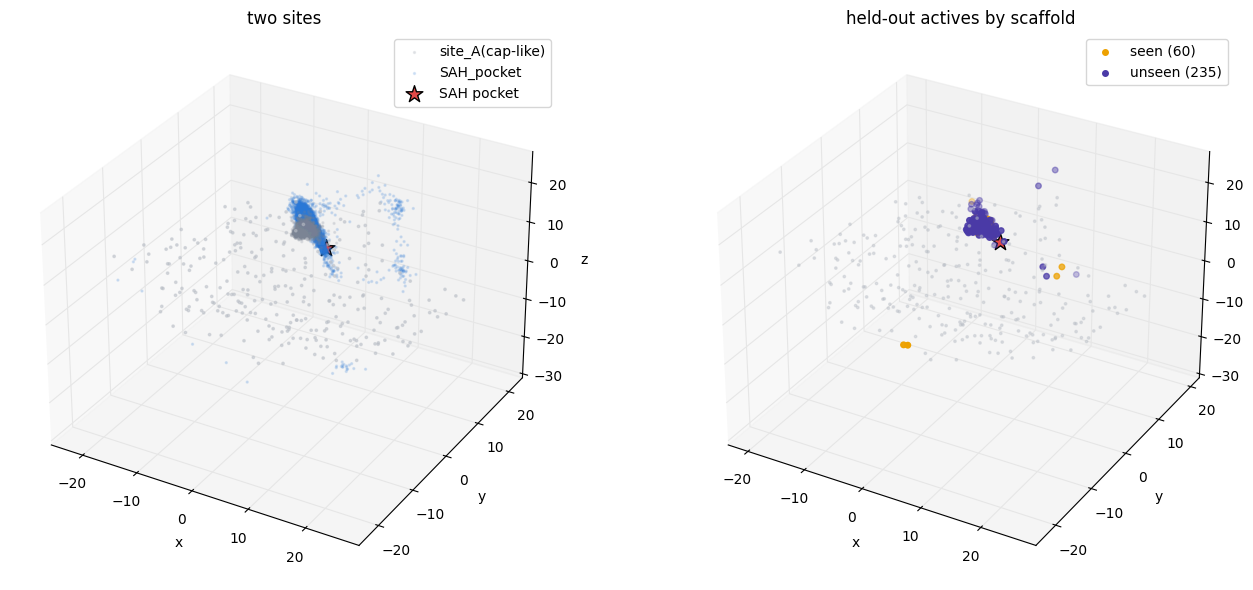

In [7]:
fig=plt.figure(figsize=(14,6)); from mpl_toolkits.mplot3d import Axes3D
A=fig.add_subplot(121,projection="3d")
A.scatter(ref_ca[:,0],ref_ca[:,1],ref_ca[:,2],s=3,color="#b9bec6",alpha=.5)
for s,c in [("site_A(cap-like)",SITEA),("SAH_pocket",SITEB)]:
    g=good[good.site==s].sample(min(4000,(good.site==s).sum()),random_state=0)
    A.scatter(g.x,g.y,g.z,s=2,color=c,alpha=.15,label=s)
A.scatter(*pocket,s=160,color=POCKET,marker="*",edgecolor="k",label="SAH pocket"); A.legend(); A.set_title("two sites")
B=fig.add_subplot(122,projection="3d")
B.scatter(ref_ca[:,0],ref_ca[:,1],ref_ca[:,2],s=3,color="#b9bec6",alpha=.4)
B.scatter(seen.x,seen.y,seen.z,s=16,color=SEEN,label=f"seen ({len(seen)})")
B.scatter(uns.x,uns.y,uns.z,s=16,color=UNSEEN,label=f"unseen ({len(uns)})")
B.scatter(*pocket,s=160,color=POCKET,marker="*",edgecolor="k"); B.legend(); B.set_title("held-out actives by scaffold")
for ax in (A,B): ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
plt.tight_layout(); plt.show()

## Site-lining residues
Which residues line each site. Site A is compared to the flavivirus NS5 GTP/cap-binding site (L17, N18, F25 region); Site B to the SAM/SAH cofactor pocket (glycine-rich G80-G83 loop, D146).

In [8]:
def nearres(c,cut=6):
    rs=set()
    for ch in m:
        if ch.name!="A": continue
        for res in ch:
            if any(np.linalg.norm(np.array([a.pos.x,a.pos.y,a.pos.z])-c)<cut for a in res): rs.add((res.seqid.num,res.name))
    return sorted(rs)
for s in ["site_A(cap-like)","SAH_pocket"]:
    c=good[good.site==s][["x","y","z"]].mean().values
    print(s, "->", [f"{n}{nm[:1]}" for n,nm in nearres(c)][:12])

site_A(cap-like) -> ['17L', '18A', '25P', '152P']
SAH_pocket -> ['105L', '110H', '133P', '147I']


## Conclusions (provisional, single target)

- Boltz-2 places ligands into two sites ~20 A apart: a majority site (~85%) whose lining residues match the NS5 GTP/cap site, and the minority SAM/SAH cofactor pocket (~15%). Confirmed not an alignment artifact.
- Placement does not discriminate actives: active rate is the same in both sites (no detectable difference), and poses are high-confidence in both, so a confidence filter would not help.
- Unseen and seen scaffolds split across the two sites the same way - scaffold-independent placement.
- The Boltz-2 score is substantially, but not entirely, reproducible from bulk ligand descriptors (RF R2~0.3; descriptor-only activity AUROC 0.845 vs 0.915).
- Held: whether the protein contributes beyond ligand properties. The decoy-protein rescore is the gating experiment; until then, do not claim the head 'scores interactions' or 'ignores the protein'.
- To do as folding finishes: recompute the 85/15 split at 80% and 90% to confirm it is stable.